In [45]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight


import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    GlobalAveragePooling1D, Dense, Dropout, Concatenate,
    Bidirectional, LSTM
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
import seaborn as sns
from sklearn.metrics import confusion_matrix


from underthesea import word_tokenize

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [46]:
data_path = "../data/processed/"

train_df = pd.read_excel(os.path.join(data_path, "train.xlsx"))
dev_df   = pd.read_excel(os.path.join(data_path, "dev.xlsx"))
test_df  = pd.read_excel(os.path.join(data_path, "test.xlsx"))

X_train_raw = train_df["clean_review"]
y_train = train_df["label"]

X_dev_raw = dev_df["clean_review"]
y_dev = dev_df["label"]

X_test_raw = test_df["clean_review"]
y_test = test_df["label"]

print("Train size:", len(X_train_raw))
print("Dev size:", len(X_dev_raw))
print("Test size:", len(X_test_raw))

Train size: 42000
Dev size: 9000
Test size: 9000


In [47]:
from collections import Counter
import numpy as np

# Gộp tất cả text (chỉ cần train là đủ, tránh leak test)
all_text = X_train_raw.astype(str).tolist()

# Tokenize đơn giản (bạn có thể thay bằng tokenizer tốt hơn)
all_tokens = []
for sentence in all_text:
    tokens = sentence.split()
    all_tokens.extend(tokens)

# Đếm tần suất
counter = Counter(all_tokens)

# Sắp xếp theo tần suất
sorted_words = counter.most_common()

# Tính coverage
freqs = np.array([freq for word, freq in sorted_words])
cumulative = np.cumsum(freqs)
coverage = cumulative / cumulative[-1]

# Tìm vocab size theo mức coverage
vocab_95 = np.where(coverage >= 0.95)[0][0]
vocab_98 = np.where(coverage >= 0.98)[0][0]

print("Vocab size (95% coverage):", vocab_95)
print("Vocab size (98% coverage):", vocab_98)

Vocab size (95% coverage): 1397
Vocab size (98% coverage): 3021


In [48]:
# Tính độ dài từng câu
lengths = [len(str(sentence).split()) for sentence in X_train_raw]

print("Max length:", np.max(lengths))
print("Mean length:", np.mean(lengths))

# Percentile
max_len_90 = int(np.percentile(lengths, 90))
max_len_95 = int(np.percentile(lengths, 95))
max_len_99 = int(np.percentile(lengths, 99))

print("MAX_LEN 90%:", max_len_90)
print("MAX_LEN 95%:", max_len_95)
print("MAX_LEN 99%:", max_len_99)

Max length: 1374
Mean length: 22.887333333333334
MAX_LEN 90%: 39
MAX_LEN 95%: 50
MAX_LEN 99%: 80


In [60]:
# Tham số cấu hình
VOCAB_SIZE = 5000  
EMBED_DIM  = 128
MAX_LEN    = 80

# Tách từ
def tokenize_vi(text):
    return word_tokenize(str(text), format="text")

X_train_raw = X_train_raw.apply(tokenize_vi)
X_dev_raw   = X_dev_raw.apply(tokenize_vi)
X_test_raw  = X_test_raw.apply(tokenize_vi)

NUM_CLASSES = len(set(y_train))

# Chuyển về numpy array để nhất quán
y_train = y_train.to_numpy() if hasattr(y_train, 'to_numpy') else np.array(y_train)
y_dev   = y_dev.to_numpy()   if hasattr(y_dev,   'to_numpy') else np.array(y_dev)
y_test  = y_test.to_numpy()  if hasattr(y_test,  'to_numpy') else np.array(y_test)


# TOKENIZER 
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_dev_seq   = tokenizer.texts_to_sequences(X_dev_raw)
X_test_seq  = tokenizer.texts_to_sequences(X_test_raw)


# PADDING
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_dev_pad   = pad_sequences(X_dev_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

# CHECK SHAPE
print(f"\nHình dạng dữ liệu sau padding:")
print(f"  X_train : {X_train_pad.shape}")
print(f"  X_dev   : {X_dev_pad.shape}")
print(f"  X_test  : {X_test_pad.shape}")



Hình dạng dữ liệu sau padding:
  X_train : (42000, 80)
  X_dev   : (9000, 80)
  X_test  : (9000, 80)


In [69]:
# HÀM TIỆN ÍCH DÙNG CHUNG
def evaluate_model(model, X, y_true, label_names=None, dataset_name="Test"):
    """
    Đánh giá mô hình với label dạng integer (sparse).
    - Macro F1-score
    - Classification report
    """
    y_prob = model.predict(X, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\n{'='*55}")
    print(f"Kết quả trên tập {dataset_name}:")
    print(f"Macro F1-score: {macro_f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

    return macro_f1


def plot_history(history, title=""):
    """Vẽ đồ thị loss và accuracy theo epoch."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"],     label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Dev Loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"],     label="Train Acc")
    axes[1].plot(history.history["val_accuracy"], label="Dev Acc")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [62]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print(class_weight_dict)

{np.int64(0): np.float64(0.9523809523809523), np.int64(1): np.float64(1.3333333333333333), np.int64(2): np.float64(0.8333333333333334)}


In [63]:

# MÔ HÌNH 1: TextCNN
CNN_FILTERS      = 128
CNN_KERNEL_SIZES = [3, 4, 5]
CNN_DROPOUT      = 0.5
CNN_BATCH_SIZE   = 64
CNN_EPOCHS       = 30
CNN_LR           = 5e-4


def build_textcnn(vocab_size, embed_dim, max_len, num_classes,
                  num_filters, kernel_sizes, dropout_rate, learning_rate):

    inputs = Input(shape=(max_len,), name="input")

    emb = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        input_length=max_len,
        name="embedding"
    )(inputs)

    branches = []
    for ks in kernel_sizes:
        conv = Conv1D(
            filters=num_filters,
            kernel_size=ks,
            activation="relu",
            name=f"conv1d_k{ks}"
        )(emb)

        pool = GlobalMaxPooling1D(name=f"maxpool_k{ks}")(conv)
        branches.append(pool)

    merged = Concatenate(name="concat")(branches)

    x = Dense(128, activation="relu", name="fc")(merged)
    x = Dropout(dropout_rate, name="dropout")(x)

    outputs = Dense(num_classes, activation="softmax", name="output")(x)

    model = Model(inputs=inputs, outputs=outputs, name="TextCNN")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",   # FIXED
        metrics=["accuracy"]
    )

    return model


# --- Khởi tạo và xem kiến trúc ---
textcnn_model = build_textcnn(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    max_len=MAX_LEN,
    num_classes=NUM_CLASSES,
    num_filters=CNN_FILTERS,
    kernel_sizes=CNN_KERNEL_SIZES,
    dropout_rate=CNN_DROPOUT,
    learning_rate=CNN_LR
)

textcnn_model.summary()

C:\Users\THUY_LINH\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "TextCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)            │ (None, 80)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 80, 128)           │         640,000 │ input[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_k3 (Conv1D)            │ (None, 78, 128)           │          49,280 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_k4 (Conv1D)            │ (None, 77, 128)           │          65,664 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_k5 (Conv1D)            │ (None, 76, 128)           │          82,048 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ maxpool_k3                    │ (None, 128)               │               0 │ conv1d_k3[0][0]            │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ maxpool_k4                    │ (None, 128)               │               0 │ conv1d_k4[0][0]            │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ maxpool_k5                    │ (None, 128)               │               0 │ conv1d_k5[0][0]            │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concat (Concatenate)          │ (None, 384)               │               0 │ maxpool_k3[0][0],          │
│                               │                           │                 │ maxpool_k4[0][0],          │
│                               │                           │                 │ maxpool_k5[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fc (Dense)                    │ (None, 128)               │          49,280 │ concat[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ fc[0][0]                   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output (Dense)                │ (None, 3)                 │             387 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 886,659 (3.38 MB)

 Trainable params: 886,659 (3.38 MB)

 Non-trainable params: 0 (0.00 B)

Bắt đầu huấn luyện TextCNN...
Epoch 1/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.6418 - loss: 0.7887
Epoch 1: val_loss improved from None to 0.42840, saving model to best_textcnn.keras

Epoch 1: finished saving model to best_textcnn.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 112s 161ms/step - accuracy: 0.7323 - loss: 0.6282 - val_accuracy: 0.8143 - val_loss: 0.4284
Epoch 2/30
656/657 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8366 - loss: 0.4199
Epoch 2: val_loss improved from 0.42840 to 0.40379, saving model to best_textcnn.keras

Epoch 2: finished saving model to best_textcnn.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 117s 178ms/step - accuracy: 0.8363 - loss: 0.4176 - val_accuracy: 0.8224 - val_loss: 0.4038
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8819 - loss: 0.3161
Epoch 3: val_loss did not improve from 0.40379
657/657 ━━━━━━━━━━━━━━━━━━━━ 122s 185ms/step - accuracy: 0.8784 - loss: 0.3244 - val_accuracy: 0.8228 - val_loss: 0.4167
Epoch 4/30
657/65

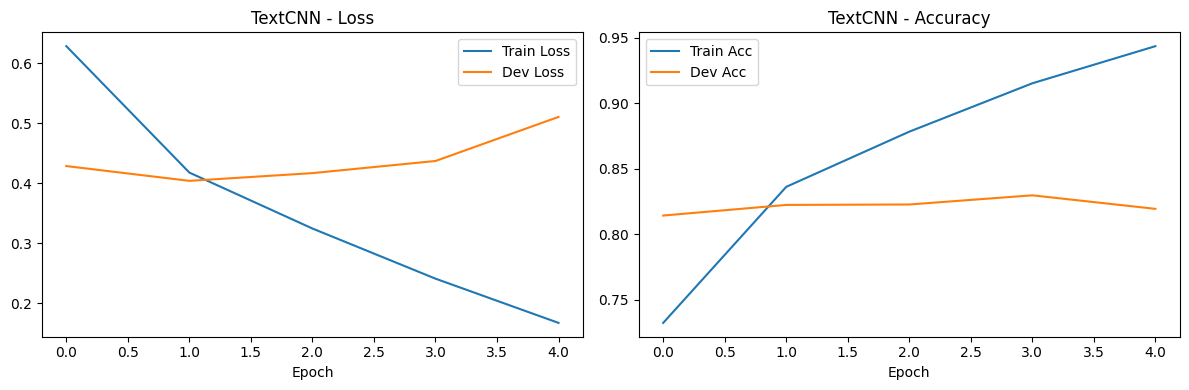

In [64]:
# Huấn luyện TextCNN

cnn_checkpoint_path = "best_textcnn.keras"

cnn_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=cnn_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Bắt đầu huấn luyện TextCNN...")

cnn_history = textcnn_model.fit(
    X_train_pad, y_train,   
    validation_data=(X_dev_pad, y_dev),  
    batch_size=CNN_BATCH_SIZE,
    class_weight=class_weight_dict,
    epochs=CNN_EPOCHS,
    callbacks=cnn_callbacks,
    verbose=1
)

plot_history(cnn_history, title="TextCNN")

In [70]:
cnn_dev_f1 = evaluate_model(
    textcnn_model, X_dev_pad, y_dev,
    dataset_name="Dev"
)

cnn_test_f1 = evaluate_model(
    textcnn_model, X_test_pad, y_test,
    dataset_name="Test"
)

print(f"\n>>> [TextCNN] Dev Macro F1  : {cnn_dev_f1:.4f}")
print(f">>> [TextCNN] Test Macro F1 : {cnn_test_f1:.4f}")



Kết quả trên tập Dev:
Macro F1-score: 0.8101
              precision    recall  f1-score   support

           0     0.8700    0.8029    0.8351      3150
           1     0.6386    0.7578    0.6931      2250
           2     0.9255    0.8800    0.9022      3600

    accuracy                         0.8224      9000
   macro avg     0.8113    0.8135    0.8101      9000
weighted avg     0.8343    0.8224    0.8264      9000


Kết quả trên tập Test:
Macro F1-score: 0.8149
              precision    recall  f1-score   support

           0     0.8794    0.8079    0.8422      3150
           1     0.6447    0.7693    0.7015      2250
           2     0.9246    0.8786    0.9010      3600

    accuracy                         0.8266      9000
   macro avg     0.8162    0.8186    0.8149      9000
weighted avg     0.8388    0.8266    0.8305      9000


>>> [TextCNN] Dev Macro F1  : 0.8101
>>> [TextCNN] Test Macro F1 : 0.8149


In [66]:
# ===================================================
# MÔ HÌNH 2: BiLSTM
# Kiến trúc:
#   Input → Embedding → BiLSTM (return_sequences=True)
#         → GlobalAveragePooling → FC + Dropout → Softmax
# ===================================================

# Siêu tham số BiLSTM 
LSTM_UNITS      = 128
LSTM_DROPOUT    = 0.5
LSTM_BATCH_SIZE = 64
LSTM_EPOCHS     = 30
LSTM_LR         = 5e-4

def build_bilstm(vocab_size, embed_dim, max_len, num_classes,
                 lstm_units, dropout_rate, learning_rate):
    """
    Xây dựng kiến trúc BiLSTM.
    Xử lý chuỗi theo cả hai chiều để nắm ngữ cảnh đầy đủ.
    GlobalAveragePooling tổng hợp toàn bộ chuỗi đầu ra thay vì chỉ
    lấy hidden state bước cuối.
    """
    inputs = Input(shape=(max_len,), name="input")

    # Lớp Embedding: khởi tạo ngẫu nhiên, huấn luyện end-to-end
    x = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        input_length=max_len,
        name="embedding"
    )(inputs)

    # BiLSTM: return_sequences=True để giữ toàn bộ chuỗi đầu ra
    x = Bidirectional(
        LSTM(units=lstm_units, return_sequences=True),
        name="bilstm"
    )(x)

    # GlobalAveragePooling: tổng hợp ngữ cảnh toàn câu
    x = GlobalAveragePooling1D(name="gap")(x)

    # Fully Connected + Dropout
    x = Dense(128, activation="relu", name="fc")(x)
    x = Dropout(dropout_rate, name="dropout")(x)

    # Output
    outputs = Dense(num_classes, activation="softmax", name="output")(x)

    model = Model(inputs=inputs, outputs=outputs, name="BiLSTM")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# --- Khởi tạo và xem kiến trúc ---
bilstm_model = build_bilstm(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    max_len=MAX_LEN,
    num_classes=NUM_CLASSES,
    lstm_units=LSTM_UNITS,
    dropout_rate=LSTM_DROPOUT,
    learning_rate=LSTM_LR
)
bilstm_model.summary()

C:\Users\THUY_LINH\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 80)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 80, 128)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bilstm (Bidirectional)               │ (None, 80, 256)             │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling1D)         │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc (Dense)                           │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 936,451 (3.57 MB)

 Trainable params: 936,451 (3.57 MB)

 Non-trainable params: 0 (0.00 B)

Bắt đầu huấn luyện BiLSTM...
Epoch 1/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.5593 - loss: 0.8801
Epoch 1: val_loss improved from None to 0.52044, saving model to best_bilstm.keras

Epoch 1: finished saving model to best_bilstm.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 243s 355ms/step - accuracy: 0.6660 - loss: 0.7398 - val_accuracy: 0.7820 - val_loss: 0.5204
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.7867 - loss: 0.5420
Epoch 2: val_loss improved from 0.52044 to 0.48560, saving model to best_bilstm.keras

Epoch 2: finished saving model to best_bilstm.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 316s 478ms/step - accuracy: 0.7896 - loss: 0.5293 - val_accuracy: 0.7924 - val_loss: 0.4856
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.8238 - loss: 0.4573
Epoch 3: val_loss improved from 0.48560 to 0.46329, saving model to best_bilstm.keras

Epoch 3: finished saving model to best_bilstm.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 291s 442ms/step - accu

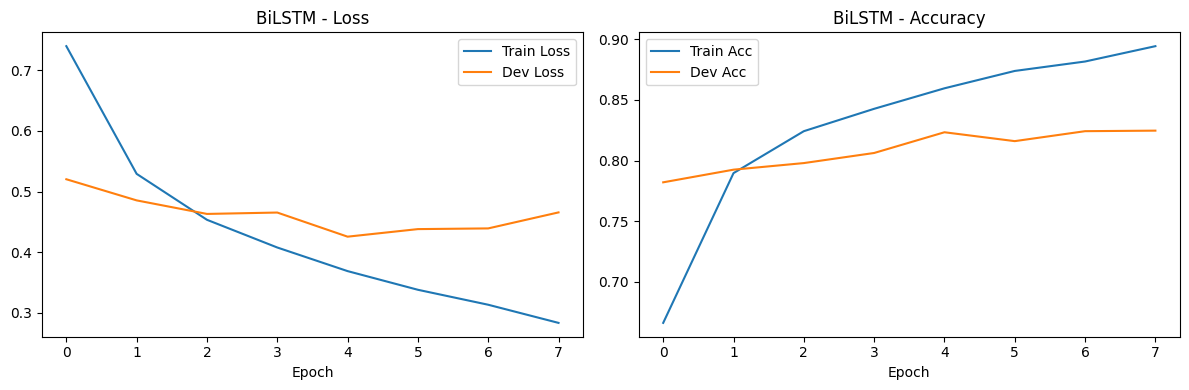

In [67]:
# --- Huấn luyện BiLSTM ---

lstm_checkpoint_path = "best_bilstm.keras"

lstm_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,                  # Dừng nếu val_loss không cải thiện sau 5 epoch
        restore_best_weights=True,   # Tự khôi phục trọng số tốt nhất
        verbose=1
    ),
    ModelCheckpoint(
        filepath=lstm_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,         # Chỉ lưu checkpoint tốt nhất trên Dev
        verbose=1
    )
]

print("Bắt đầu huấn luyện BiLSTM...")
lstm_history = bilstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_dev_pad, y_dev),
    batch_size=LSTM_BATCH_SIZE,
    class_weight=class_weight_dict,
    epochs=LSTM_EPOCHS,
    callbacks=lstm_callbacks,
    verbose=1
)

plot_history(lstm_history, title="BiLSTM")

In [71]:
# --- Đánh giá BiLSTM ---
lstm_dev_f1 = evaluate_model(
    bilstm_model,
    X_dev_pad,
    y_dev,
    dataset_name="Dev"
)

lstm_test_f1 = evaluate_model(
    bilstm_model,
    X_test_pad,
    y_test,
    dataset_name="Test"
)
print(f"\n>>> [BiLSTM] Dev Macro F1  : {lstm_dev_f1:.4f}")
print(f">>> [BiLSTM] Test Macro F1 : {lstm_test_f1:.4f}")



Kết quả trên tập Dev:
Macro F1-score: 0.8085
              precision    recall  f1-score   support

           0     0.8621    0.8137    0.8372      3150
           1     0.6491    0.7227    0.6839      2250
           2     0.9145    0.8947    0.9045      3600

    accuracy                         0.8233      9000
   macro avg     0.8086    0.8103    0.8085      9000
weighted avg     0.8298    0.8233    0.8258      9000


Kết quả trên tập Test:
Macro F1-score: 0.8045
              precision    recall  f1-score   support

           0     0.8683    0.8124    0.8394      3150
           1     0.6408    0.7182    0.6773      2250
           2     0.9057    0.8883    0.8969      3600

    accuracy                         0.8192      9000
   macro avg     0.8049    0.8063    0.8045      9000
weighted avg     0.8264    0.8192    0.8219      9000


>>> [BiLSTM] Dev Macro F1  : 0.8085
>>> [BiLSTM] Test Macro F1 : 0.8045


240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step


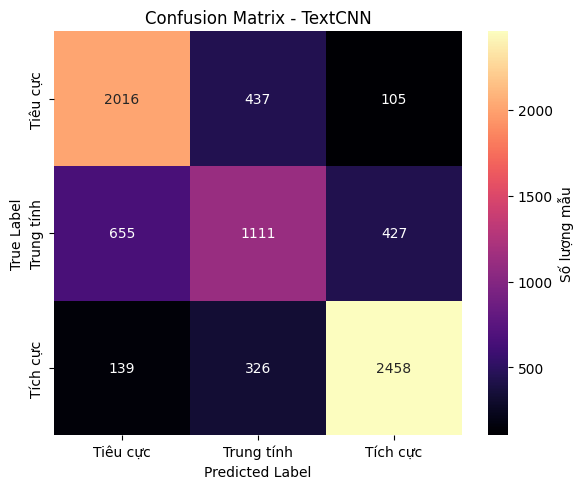

240/240 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step


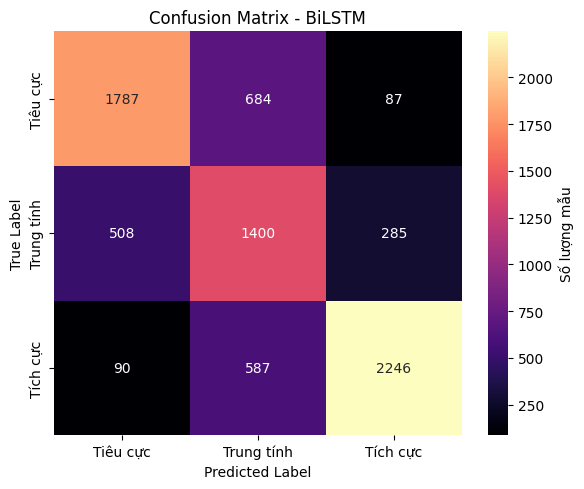

In [28]:
labels = ["Tiêu cực", "Trung tính", "Tích cực"]
class_names = labels  

def plot_cm_heatmap(model, X, y_true, title):
    
    y_pred = model.predict(X)

    # nếu one-hot → đổi về label
    if len(y_true.shape) > 1:
        y_true = np.argmax(y_true, axis=1)
    if len(y_pred.shape) > 1:
        y_pred = np.argmax(y_pred, axis=1)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,              # hiển thị số trong ô
        fmt="d",                 # định dạng số nguyên
        cmap="magma",            
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={"label": "Số lượng mẫu"}
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# TextCNN
plot_cm_heatmap(textcnn_model, X_test_pad, y_test, "Confusion Matrix - TextCNN")

# BiLSTM
plot_cm_heatmap(bilstm_model, X_test_pad, y_test, "Confusion Matrix - BiLSTM")